# Spatial Transcriptomics Analysis

## Setup Environment

In [ ]:
# This is not necessary on Google Colab!
%conda install -c conda-forge cupy

In [ ]:
%pip install git+https://github.com/pnucolab/stLENS

In [3]:
%pip install spatialdata-io spatialdata-plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [spatialdata-plot]
Note: you may need to restart the kernel to use updated packages.


## Visium HD

### Load data

In [1]:
import spatialdata as sd
sdata = sd.read_zarr("visiumhd_sdata_cropped.zarr")
sdata

/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning:

SpatialData object, with associated Zarr store: /bce/groups/pnucolab/users/parkj/projects/stlens/biml-2025/visiumhd_sdata_cropped.zarr
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_hires_image': DataArray[cyx] (3, 843, 844)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_lowres_image': DataArray[cyx] (3, 84, 84)
├── Shapes
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_002um': GeoDataFrame shape: (1849989, 1) (2D shapes)
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_008um': GeoDataFrame shape: (116132, 1) (2D shapes)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_square_016um': GeoDataFrame shape: (29232, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (1849989, 18085)
      ├── 'square_008um': AnnData (116132, 18085)
      └── 'square_016um': AnnData (29232, 18085)
with coordinate systems:
    ▸ 'Visium_HD_Human_Colon_Cancer_P1', with elements:
        Visium_HD_Human_Colon_Cancer_P1_hires_image (Images), Visium_HD_Human_Colon_Cancer_P1_lowres_image (Images), Visium_

In [5]:
import scanpy as sc
adata = sdata.tables['square_008um']

/tmp/ipykernel_3208089/3159902038.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)


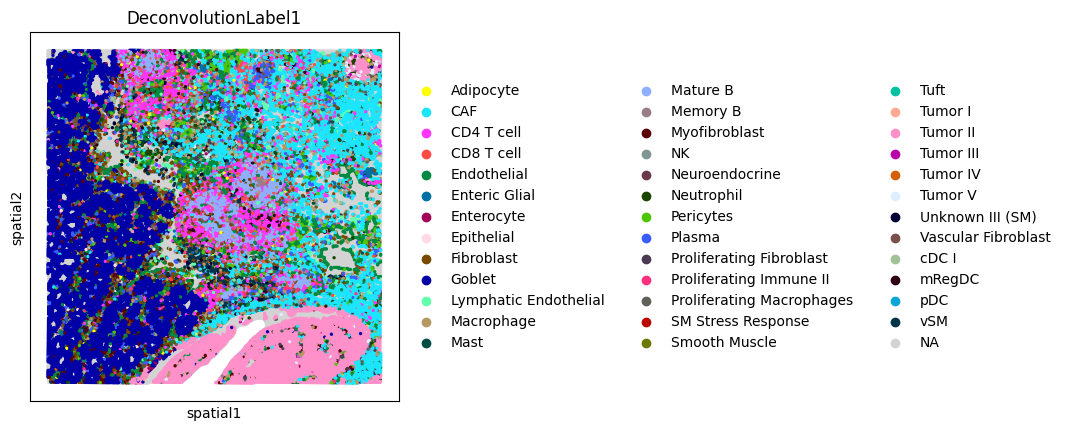

In [6]:
sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)

### Quality Control & Normalization

Filtering with stLENS:

In [7]:
from stLENS import stLENS
stlens = stLENS()

/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
stlens.filter_cells_and_genes(adata, mito_percent=20)

/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/stLENS/stLENS.py:186: RuntimeWarning: invalid value encountered in divide
  mito_ratio = np.array(mito_sum / total_sum).flatten()


After filtering >> shape: (26966, 15608)


Optional: Filtering with Scanpy:

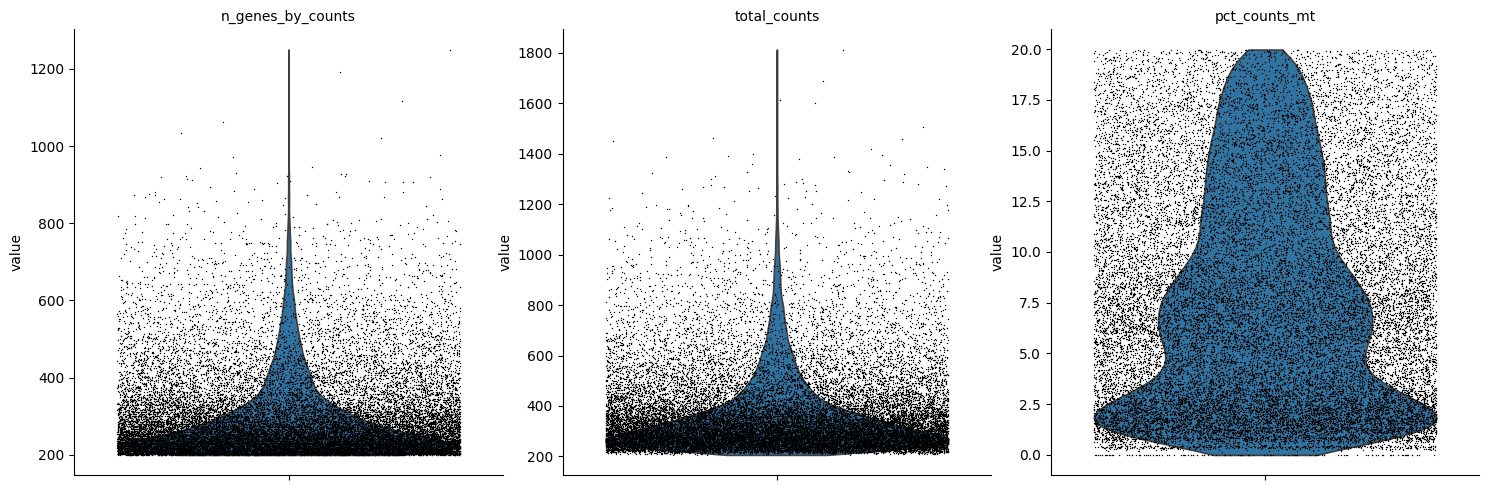

In [92]:
import scanpy as sc

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=False, log1p=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)
adata = adata[adata.obs.pct_counts_mt < 20, :]

Visualize filtered adata

/tmp/ipykernel_3208089/3159902038.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)


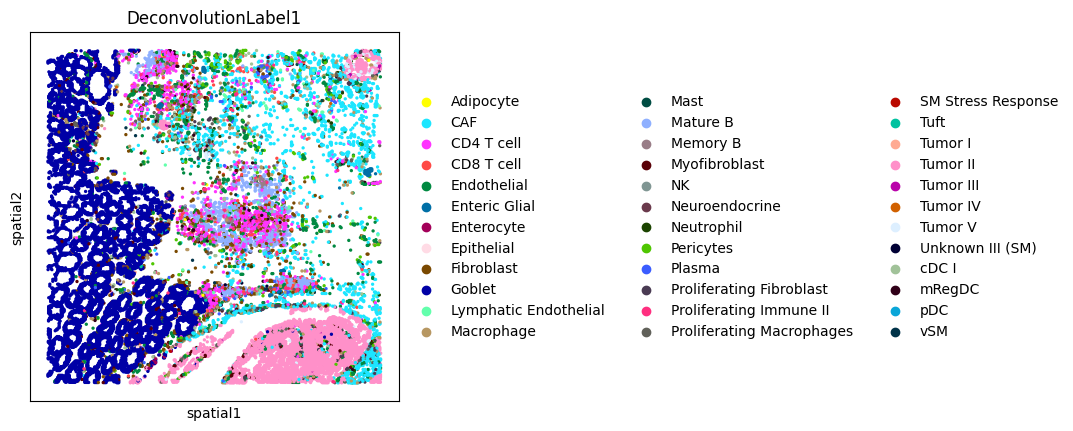

In [9]:
sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)

### PCA

In [ ]:
from stLENS import stLENS
import scanpy as sc
stlens = stLENS()

/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


sparsity_th: 0.03295568217768125


/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Min(corr): 0.03758801892399788, sparsity: 0.999


/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


...

Min(corr): 0.030909553170204163, sparsity: 0.995


/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Min(corr): 0.030213816091418266, sparsity: 0.994


/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Min(corr): 0.029641013592481613, sparsity: 0.993
Max interactions exceeded!
lambda_c: 5.004815
Number of signal: 80


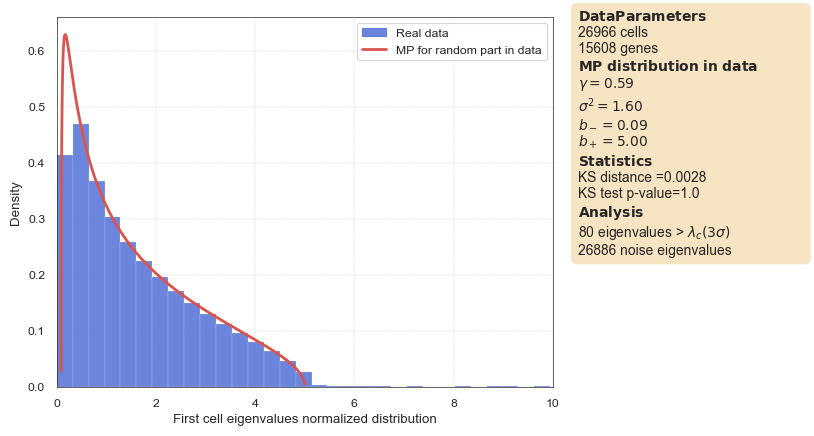

  0%|          | 0/20 [00:00<?, ?it/s]/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  5%|▌         | 1/20 [00:16<05:15, 16.58s/it]/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 10%|█         | 2/20 [00:32<04:53, 16.30s/it]/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 15%|█▌        | 3/20 [00:49<04:38, 16.40s/it]/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring

number of filtered signals: 26


26

In [11]:
stlens.find_optimal_pc(adata, plot_mp=True)

In [12]:
n_comps = adata.uns['stlens']['optimal_pc_count']
print("Optimal number of PCs:", n_comps)

Optimal number of PCs: 26


In [13]:
# PCA transformation using stLENS’s pca function
# Note that the PCA result is l2 normalized - thus all the downstream analyses should use cosine distance as the metric.
stlens.pca(adata)

In [14]:
adata.obsm['X_pca_stlens']

array([[ 0.00954213, -0.00310966,  0.00309129, ..., -0.00327145,
        -0.09188442,  0.03998631],
       [-0.00620765, -0.00592603,  0.00891101, ...,  0.00988002,
        -0.04318553,  0.01984949],
       [-0.02044461,  0.00172539, -0.01001313, ...,  0.08908678,
         0.00093755, -0.05465166],
       ...,
       [ 0.0108533 ,  0.00261236, -0.00098609, ...,  0.00324986,
        -0.03665039,  0.0176645 ],
       [ 0.00140312, -0.00501728,  0.01115828, ..., -0.04584608,
         0.04861146, -0.09748109],
       [-0.00068422,  0.00210056,  0.00343749, ...,  0.02194603,
        -0.04136275,  0.00573214]], shape=(26966, 26))

Find clusters using stLENS PCA result

In [15]:
sc.pp.neighbors(adata, use_rep='X_pca_stlens', metric='cosine')
sc.tl.leiden(adata, flavor='igraph', n_iterations=2)

/tmp/ipykernel_3208089/2213031558.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden', spot_size=100)


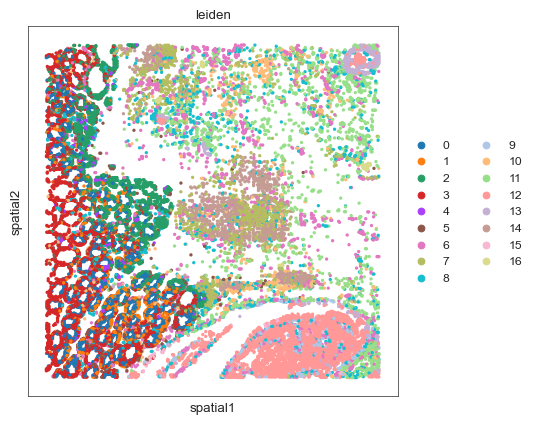

In [16]:
sc.pl.spatial(adata, color='leiden', spot_size=100)

Find clusters using Scanpy default

In [17]:
# You can also use Scanpy’s PCA function with the optimal number of principal components determined by stLENS.
sc.pp.pca(adata)
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.leiden(adata, key_added='leiden_scanpy', flavor='igraph', n_iterations=2)

/tmp/ipykernel_3208089/2040562915.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden_scanpy', spot_size=100)


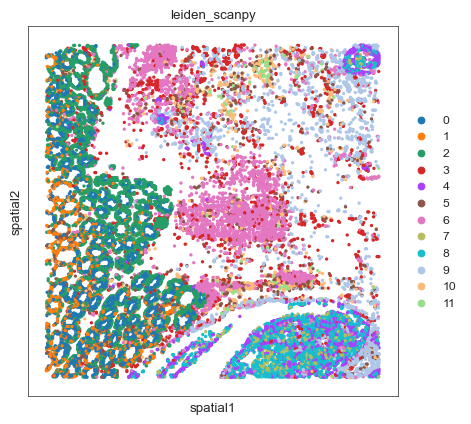

In [18]:
sc.pl.spatial(adata, color='leiden_scanpy', spot_size=100)

Comparing the clustering results with the ground truth

In [64]:
# find cluster centroids
import numpy as np
from scipy.spatial import distance
def find_cluster_centroids(adata, cluster_key):
    centroids = []
    for cluster in adata.obs[cluster_key].cat.categories:
        cluster_cells = adata[adata.obs[cluster_key] == cluster]
        centroid = np.array(np.mean(np.log1p(cluster_cells.X), axis=0)).flatten()
        centroids.append(centroid)
    return np.array(centroids)

centroids_gt = find_cluster_centroids(adata, 'DeconvolutionLabel1')
centroids_stlens = find_cluster_centroids(adata, 'leiden')
centroids_scanpy = find_cluster_centroids(adata, 'leiden_scanpy')

distances_stlens = distance.cdist(
    centroids_stlens, 
    centroids_gt,
    metric='correlation'
)
distances_scanpy = distance.cdist(
    centroids_scanpy,
    centroids_gt,
    metric='correlation'
)

closest_stlens = np.argmin(distances_stlens, axis=1)
closest_scanpy = np.argmin(distances_scanpy, axis=1)

adata.uns['leiden_colors'] = adata.uns['DeconvolutionLabel1_colors'][closest_stlens]
adata.uns['leiden_scanpy_colors'] = adata.uns['DeconvolutionLabel1_colors'][closest_scanpy]

In [74]:
print("Number of unique clusters found using stLENS:", len(set(closest_stlens)))
print("Number of unique clusters found using Scanpy:", len(set(closest_scanpy)))

Number of unique clusters found using stLENS: 11
Number of unique clusters found using Scanpy: 7


/tmp/ipykernel_3208089/85957765.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


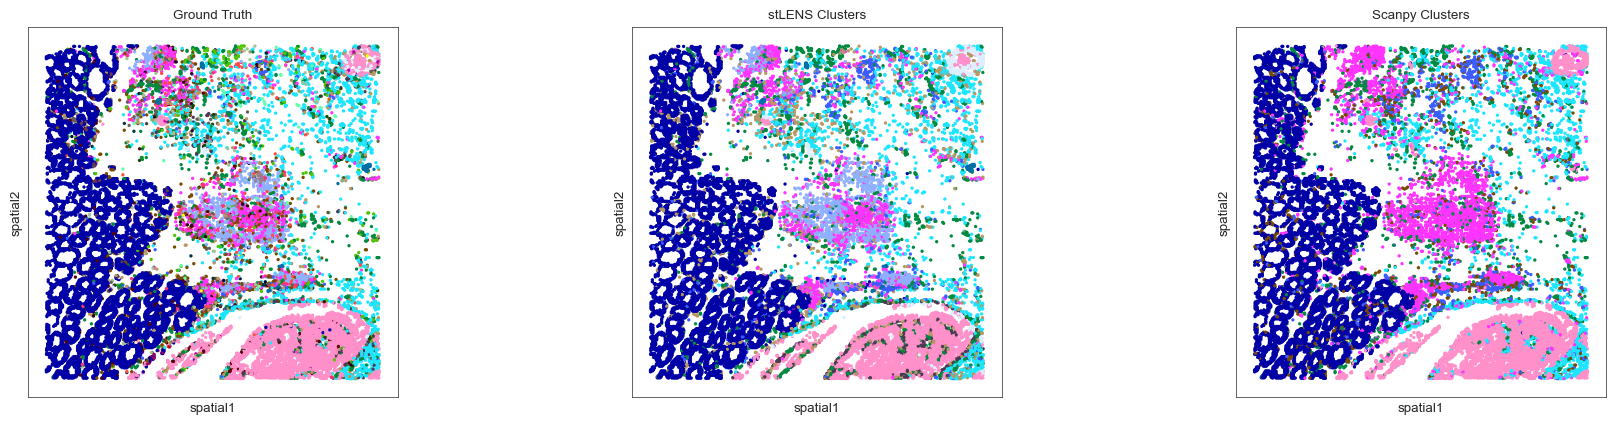

In [65]:
sc.pl.spatial(
    adata, 
    color=['DeconvolutionLabel1', 'leiden', 'leiden_scanpy'],
    spot_size=100,
    title=['Ground Truth', 'stLENS Clusters', 'Scanpy Clusters'],
    legend_loc='none'
)

In [19]:
adata

AnnData object with n_obs × n_vars = 26966 × 15608
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'leiden', 'leiden_scanpy'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'region_colors', 'spatialdata_attrs', 'stlens', 'neighbors', 'leiden', 'leiden_colors', 'pca', 'leiden_scanpy', 'leiden_scanpy_colors'
    obsm: 'spatial', 'X_pca_stlens', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## STOmics

In [21]:
import shutil
import os

stlens.directory = './output/stomics'

if os.path.exists(stlens.directory):
    shutil.rmtree(stlens.directory)  
os.makedirs(stlens.directory)

### Load data

In [19]:
!wget -P ./data/stomics https://ftp.cngb.org/pub/SciRAID/stomics/STDS0000058/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad


--2025-07-21 21:06:03--  https://ftp.cngb.org/pub/SciRAID/stomics/STDS0000058/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad
Resolving ftp.cngb.org (ftp.cngb.org)... 101.126.80.204
Connecting to ftp.cngb.org (ftp.cngb.org)|101.126.80.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 732847864 (699M) [application/octet-stream]
Saving to: ‘./data/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad’

E16.5_E1S3_cell_bin 100%[===================>] 698.90M  5.16MB/s    in 2m 26s  

2025-07-21 21:08:33 (4.78 MB/s) - ‘./data/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad’ saved [732847864/732847864]



In [20]:
adata = sc.read_h5ad('./data/stomics/E16.5_E1S3_cell_bin_whole_brain.h5ad')
adata

AnnData object with n_obs × n_vars = 65303 × 23368
    obs: 'Slice', 'region', 'sim anno', 'n_genes_by_counts', 'total_counts', 'annotation'
    var: 'Gene', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sim anno_colors'
    obsm: 'spatial'
    layers: 'counts'

### Quality Control & Normalization

Filtering with stLENS:

In [ ]:
stlens.preprocess(adata, filter=True, plot=True)

Filtering with Scanpy (conventional method):

In [ ]:
import scanpy as sc

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=False, log1p=True
)

adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)

stlens.preprocess(adata, filter=False, plot=True)

### PCA

In [ ]:
num = stlens.find_optimal_pc(plot_mp = True)

In [ ]:
# PCA transformation using stLENS’s calc_pca function
stlens.calc_pca()

In [ ]:
# You can use Scanpy’s PCA function with the optimal number of principal components determined by stLENS.
# sc.pp.pca(adata, n_comps=num)